# Comparaison des Modèles de Machine Learning et Statistiques
Ce notebook charge les modèles entraînés, calcule les prédictions pour les modèles statistiques (Dixon-Coles), puis compare leurs performances métriques et financières (ROI/Profits).

In [2]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scikit_posthocs as sp
from scipy.stats import poisson
import scipy.stats as stats
from scipy.optimize import minimize
from sklearn.metrics import (log_loss, precision_score, recall_score, f1_score, accuracy_score, brier_score_loss)

import xgboost
import lightgbm
import os
import sys

if os.getcwd().endswith('goal_based'):
    os.chdir('../..')
    print(f"Répertoire de travail calé sur la racine : {os.getcwd()}")

sys.path.append(os.path.abspath('code'))

import config as conf

Répertoire de travail calé sur la racine : d:\MATTH\Etudes\La_Rochelle\git_stage_M1\stage_m1


## Configuration Globale

In [3]:
DATA_PATH = conf.path_clean_cell
MODELS_DIR = "models"
SPLIT_RATIO = 0.8
TARGET_BIN = "Hvs"
MISE = 10
MAX_GOALS = 10
K_SMOOTHING = 5
SEUIL_SECURISE = 0.65

MODELS_CONFIG = {
    "LogisticRegression (Base)": ("LogisticRegression_Base", 0.68),
    "LogisticRegression (Optimisé)": ("LogisticRegression_Optimisé", 0.68),
    "RandomForest (base)": ("RandomForest", 0.81),
    "RandomForest (Optimisé)": ("RandomForest_optimisé", 0.67),
    "XGBoost (Base)": ("XGBoost_Base", 0.75),
    "XGBoost (Optimisé)": ("XGBoost_Optimisé", 0.66),
    "SVM RBF (base)": ("SVM_RBF_base", 0.68),
    "SVM RBF (Optimisé)": ("SVM_RBF_Optimisé", 0.65),
    "LightGBM (Base)": ("LightGBM_Base", 0.73),
    "LightGBM (Optimisé)": ("LightGBM_Optimisé", 0.68),
    "MLP (Base)": ("MLP_Base", 0.62),
    "MLP (Optimisé)": ("MLP_Optimisé", 0.68)
}

## Chargement et Préparation des Données

In [4]:
df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

split_idx = int(len(df) * SPLIT_RATIO)
df_test = df.iloc[split_idx:].copy()
y_test = df_test[TARGET_BIN].values
cotes_test = df_test.get("BWH", df_test.get("AvgH", 2.0)).values

X_test_brut_commune = df_test[conf.ft_commune]
X_test_brut_nn = df_test[conf.ft_nn]

In [5]:
def load_models(models_dir=MODELS_DIR):
    trained = {}
    for nom, cfg in MODELS_CONFIG.items():
        nom_fichier, seuil_opt = cfg
        path = os.path.join(models_dir, f"{nom_fichier}.pkl")
        if os.path.exists(path):
            trained[nom] = (joblib.load(path), seuil_opt)
            print(f"{nom}")
        else:
            print(f" {nom} introuvable,")

    if not trained:
        raise FileNotFoundError(f"Aucun modèle chargé depuis '{models_dir}/'.")
    return trained

modeles_ml = load_models( MODELS_DIR)

def get_X_test(model):
    if model.startswith("MLP"):
        return X_test_brut_nn
    return X_test_brut_commune

C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\mat

LogisticRegression (Base)
LogisticRegression (Optimisé)


C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


RandomForest (base)
RandomForest (Optimisé)
XGBoost (Base)
XGBoost (Optimisé)
SVM RBF (base)
SVM RBF (Optimisé)
LightGBM (Base)
LightGBM (Optimisé)
MLP (Base)
MLP (Optimisé)


C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelBinarizer from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MLPClassifier from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## Modèles Statistiques : Dixon-Coles (Base & Temporel)

In [6]:
def build_dixon_coles_lambdas(df_full, k=K_SMOOTHING):
    toutes_equipes = set(df_full["HomeTeam"].unique()) | set(df_full["AwayTeam"].unique())
    goals_m_dom = {t: 0 for t in toutes_equipes}
    goals_e_dom = {t: 0 for t in toutes_equipes}
    goals_m_ext = {t: 0 for t in toutes_equipes}
    goals_e_ext = {t: 0 for t in toutes_equipes}
    m_joues_dom = {t: 0 for t in toutes_equipes}
    m_joues_ext = {t: 0 for t in toutes_equipes}
    tot_b_dom, tot_b_ext, tot_m = 0, 0, 0

    mu_all, nu_all = [], []
    home_teams = df_full["HomeTeam"].values
    away_teams = df_full["AwayTeam"].values
    fthg = df_full["FTHG"].values
    ftag = df_full["FTAG"].values

    for i in range(len(df_full)):
        h, a = home_teams[i], away_teams[i]
        if tot_m > 0:
            moy_dom = max(tot_b_dom / tot_m, 0.1)
            moy_ext = max(tot_b_ext / tot_m, 0.1)
        else:
            moy_dom, moy_ext = 1.5, 1
        alpha_h = ((goals_m_dom[h] + k * moy_dom) / (m_joues_dom[h] + k)) / moy_dom
        delta_h = ((goals_e_dom[h] + k * moy_ext) / (m_joues_dom[h] + k)) / moy_ext
        beta_a = ((goals_e_ext[a] + k * moy_dom) / (m_joues_ext[a] + k)) / moy_dom
        gamma_a = ((goals_m_ext[a] + k * moy_ext) / (m_joues_ext[a] + k)) / moy_ext

        mu_all.append(alpha_h * beta_a * moy_dom)
        nu_all.append(gamma_a * delta_h * moy_ext)

        goals_m_dom[h] += fthg[i]
        goals_e_dom[h] += ftag[i]
        goals_m_ext[a] += ftag[i]
        goals_e_ext[a] += fthg[i]
        m_joues_dom[h] += 1
        m_joues_ext[a] += 1
        tot_b_dom += fthg[i]
        tot_b_ext += ftag[i]
        tot_m += 1

    return mu_all, nu_all

def tau(x, y, mu, nu, rho):
    if x == 0 and y == 0: return 1 - mu * nu * rho
    if x == 0 and y == 1: return 1 + mu * rho
    if x == 1 and y == 0: return 1 + nu * rho
    if x == 1 and y == 1: return 1 - rho
    return 1.0

def neg_log_L_base(params, mu, nu, x, y):
    rho = params[0]
    if abs(rho) > 1:
        return 1e6
    t_factors = np.array([tau(xi, yi, mi, ni, rho) for xi, yi, mi, ni in zip(x, y, mu, nu)])
    if np.any(t_factors <= 0):
        return 1e6
    return -(np.log(poisson.pmf(x, mu)) + np.log(poisson.pmf(y, nu)) + np.log(t_factors)).sum()

def neg_log_L_temporal(params, mu, nu, y_home, y_away, t_array):
    rho, xi = params
    penalite = 0.0
    if xi < 0:
        penalite += 1e7 * abs(xi)
        xi = 0.0

    tau_val = np.ones(len(y_home))
    m00 = (y_home == 0) & (y_away == 0)
    m01 = (y_home == 0) & (y_away == 1)
    m10 = (y_home == 1) & (y_away == 0)
    m11 = (y_home == 1) & (y_away == 1)
    tau_val[m00] = 1 - mu[m00] * nu[m00] * rho
    tau_val[m01] = 1 + mu[m01] * rho
    tau_val[m10] = 1 + nu[m10] * rho
    tau_val[m11] = 1 - rho

    if np.any(tau_val <= 0):
        return 1e8 + np.abs(tau_val[tau_val <= 0]).sum() + penalite

    log_match = np.log(tau_val) + poisson.logpmf(y_home, mu) + poisson.logpmf(y_away, nu)
    if not np.all(np.isfinite(log_match)):
        return 1e8 + penalite

    phi = np.exp(-t_array * xi)
    return -np.sum(phi * log_match) + penalite

## Optimisation et Inférence Statistiques

In [7]:
mu_tous, nu_tous = build_dixon_coles_lambdas(df)
mu_arr = np.array(mu_tous)
nu_arr = np.array(nu_tous)

mu_train = mu_arr[:split_idx]
nu_train = nu_arr[:split_idx]
fthg_train = df["FTHG"].values[:split_idx]
ftag_train = df["FTAG"].values[:split_idx]

df_train_time = df.iloc[:split_idx].copy()
date_max_train = df_train_time["Date"].max()
t_train_semi = ((date_max_train - df_train_time["Date"]).dt.days / 3.5).values

print("Optimisation Dixon-Coles Base (rho)")
res_base = minimize(neg_log_L_base, [0.0], args=(mu_train, nu_train, fthg_train, ftag_train), method='Nelder-Mead')
rho_base_opt = res_base.x[0]
print(rho_base_opt)

print("Optimisation Dixon-Coles Temporel (rho + xi)")
res_temp = minimize(neg_log_L_temporal, [0.0, 0.0065], args=(mu_train, nu_train, fthg_train, ftag_train, t_train_semi),
                    method='L-BFGS-B', bounds=[(-0.25, 0.10), (0.0, 0.05)])
rho_temp_opt, xi_opt = res_temp.x
print(rho_temp_opt, xi_opt)

mu_test = mu_arr[split_idx:]
nu_test = nu_arr[split_idx:]
buts = np.arange(MAX_GOALS)

probs_dc_base, probs_dc_temp = [], []
for mu_val, nu_val in zip(mu_test, nu_test):
    mat = np.outer(poisson.pmf(buts, mu_val), poisson.pmf(buts, nu_val))
    mat_base = mat.copy()
    mat_temp = mat.copy()
    for x in [0, 1]:
        for y in [0, 1]:
            mat_base[x, y] *= tau(x, y, mu_val, nu_val, rho_base_opt)
            mat_temp[x, y] *= tau(x, y, mu_val, nu_val, rho_temp_opt)
    probs_dc_base.append(np.sum(np.tril(mat_base, -1)))
    probs_dc_temp.append(np.sum(np.tril(mat_temp, -1)))

probs_dc_home = np.array(probs_dc_base)
probs_dc_temp_home = np.array(probs_dc_temp)

probas_baseline = np.full(len(y_test), 1.0 - 1e-15)
preds_baseline = np.ones(len(y_test), dtype=int)

Optimisation Dixon-Coles Base (rho)
-0.05581250000000001
Optimisation Dixon-Coles Temporel (rho + xi)
-0.07462169849567347 0.05


## Modèles Financiers : Simulation de Paris (Value Bet)

In [8]:
dict_profits_cumules = {}
dict_nb_paris = {}
dict_y_pred_binaires = {}

def simuler_value_bet(probs_pred, cotes, y_true, nom_modele, critere_decision=None, est_ml=True, mise=MISE):
    prob_bk = 1.0 / cotes
    mask = (probs_pred >= critere_decision) if est_ml else (probs_pred > prob_bk)

    gains = np.where(mask & (y_true == 1), mise * cotes, 0.0)
    mises = np.where(mask, mise, 0.0)
    profits = gains - mises

    dict_profits_cumules[nom_modele] = np.cumsum(profits)
    dict_y_pred_binaires[nom_modele] = mask.astype(int)
    dict_nb_paris[nom_modele] = int(mask.sum())

    total_investi = mask.sum() * mise
    if total_investi == 0:
        return {"Modèle": nom_modele, "Total Mise ": 0, "Profit Net ": 0.0, "ROI ": 0.0}

    profit_net = profits.sum()
    return {
        "Modèle": nom_modele,
        "Total Mise ": int(total_investi),
        "Profit Net ": round(profit_net, 2),
        "ROI ": round((profit_net / total_investi) * 100, 2),
    }

def compute_roi_par_modele(y_test, probas, cotes, seuil_optimal):
    y_t = np.array(y_test)
    c = np.array(cotes)
    p = np.array(probas)

    prob_bookmaker = 1 / c
    is_value = (p > prob_bookmaker)
    mises = np.zeros(len(p))
    mises[(p >= seuil_optimal) & (p < seuil_optimal + 0.10) & is_value] = 10.0
    mises[(p >= seuil_optimal + 0.10) & (p <= 1.0) & is_value] = 30.0
    mask = (mises > 0)
    total_mise = mises[mask].sum()
    if total_mise == 0:
        return 0.0, 0, 0.0
    gains = np.where(y_t[mask] == 1, mises[mask] * c[mask], 0.0)
    profit_net = gains.sum() - total_mise
    roi = (profit_net / total_mise) * 100

    return roi, int(total_mise), profit_net

## Regroupement des Prédictions et Calcul Globaux

In [9]:
dict_probs_tous = {
    "Baseline (Toujours 1)": probas_baseline,
    "Dixon-Coles (Stats)": probs_dc_home,
    "Dixon-Coles (Optimisé + Temps)": probs_dc_temp_home,
}
for nom, (model, seuil) in modeles_ml.items():
    dict_probs_tous[nom] = model.predict_proba(get_X_test(nom))[:, 1]

specs = {
    "Baseline (Toujours 1)": (probas_baseline, None, False),
    "Dixon-Coles (Stats)": (probs_dc_home, None, False),
    "Dixon-Coles (Optimisé + Temps)": (probs_dc_temp_home, None, False),
}
for nom, (model, seuil) in modeles_ml.items():
    specs[nom] = (dict_probs_tous[nom], seuil, True)

bilan_metriques = []
bilan_data_dynamique = []

for nom, (probas, seuil, est_ml) in specs.items():
    if est_ml and seuil is not None:
        y_pred_opti = (probas >= seuil).astype(int)
    elif not est_ml:
        y_pred_opti = (probas > (1.0 / cotes_test)).astype(int)
    else:
        y_pred_opti = preds_baseline
    y_pred_050 = (probas >= 0.50).astype(int)

    bilan_metriques.append({
        "Modèle": nom,
        "Seuil": round(seuil, 2) if (seuil is not None) else ("VB" if not est_ml else "0.50"),
        "Log-Loss": round(log_loss(y_test, probas), 4),
        "Brier Score": round(brier_score_loss(y_test, probas), 4),
        "|": "|",
        "Accuracy (0.5)": round(accuracy_score(y_test, y_pred_050), 3),
        "F1 (0.5)": round(f1_score(y_test, y_pred_050, zero_division=0), 3),
        "Précision (0.5)": round(precision_score(y_test, y_pred_050, zero_division=0), 3),
        "Recall": round(recall_score(y_test, y_pred_050, zero_division=0), 3),
        "||": "||",
        "Accuracy (Opti)": round(accuracy_score(y_test, y_pred_opti), 3),
        "F1 (Opti)": round(f1_score(y_test, y_pred_opti, zero_division=0), 3),
        "Précision (Opti)": round(precision_score(y_test, y_pred_opti, zero_division=0), 3),
        "Recall (Opti)": round(recall_score(y_test, y_pred_opti, zero_division=0), 3),
    })

    if nom == "Baseline (Toujours 1)":
        profits = np.where(y_test == 1, MISE * cotes_test, 0.0) - MISE
        dict_profits_cumules[nom] = np.cumsum(profits)
        dict_y_pred_binaires[nom] = preds_baseline
        dict_nb_paris[nom] = len(y_test)
        total_investi = len(y_test) * MISE
        roi_base = round((profits.sum() / total_investi) * 100, 2)
        profit_base = round(profits.sum(), 1)

        bilan_data_dynamique.append({
            "Modèle": nom, "Seuil Opti": "1.00",
            "ROI Std 0.50 ": roi_base, "Profit Std": profit_base, "|": "|",
            "ROI Seuil opti ": roi_base, "Profit Sécu": profit_base, "mise Sécu": int(total_investi),
            "||": "||",
            "ROI Dyn Opti ": roi_base, "Profit Dyn": profit_base, "mise Dyn": int(total_investi),
        })
    else:
        mask_std = (probas >= 0.50)
        profit_std = (np.where(mask_std & (y_test == 1), MISE * cotes_test, 0.0) - np.where(mask_std, MISE, 0.0)).sum()
        roi_std = (profit_std / (mask_std.sum() * MISE) * 100) if mask_std.sum() > 0 else 0.0

        seuil_concret = seuil if (seuil is not None) else SEUIL_SECURISE
        res_sec = simuler_value_bet(probas, cotes_test, y_test, nom, critere_decision=seuil_concret, est_ml=est_ml)
        roi_sec, mise_sec, profit_sec = res_sec["ROI "], res_sec["Total Mise "], res_sec["Profit Net "]

        roi_dyn, mise_dyn, profit_dyn = compute_roi_par_modele(y_test, probas, cotes_test, seuil_concret)

        bilan_data_dynamique.append({
            "Modèle": nom,
            "Seuil Opti": round(seuil, 2) if (seuil is not None) else "VB",
            "ROI Std 0.50 ": round(roi_std, 2), "Profit Std": round(profit_std, 1), "|": "|",
            "ROI Seuil opti ": round(roi_sec, 2), "Profit Sécu": round(profit_sec, 1), "mise Sécu": int(mise_sec),
            "||": "||",
            "ROI Dyn Opti ": round(roi_dyn, 2), "Profit Dyn": round(profit_dyn, 1), "mise Dyn": int(mise_dyn),
        })

## Synthèse sous forme de Tableaux

In [10]:
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', None)
df_metriques = pd.DataFrame(bilan_metriques)

print("\n" + "=" * 140)
print("           MÉTRIQUES DE CLASSIFICATION")
print("=" * 140)
print(df_metriques.sort_values("Log-Loss", ascending=True).to_string(index=False))
print("=" * 140)

df_comparatif = pd.DataFrame(bilan_data_dynamique)
df_comparatif_trie = df_comparatif.sort_values("ROI Dyn Opti ", ascending=False).copy()

print("\n" + "=" * 140)
print("       PERFORMANCES FINANCIÈRES COMPARÉES (ROI en (%),  PROFITS)")
print("=" * 140)
print(df_comparatif_trie.to_string(index=False))
print("=" * 140)


           MÉTRIQUES DE CLASSIFICATION
                        Modèle Seuil  Log-Loss  Brier Score |  Accuracy (0.5)  F1 (0.5)  Précision (0.5)  Recall ||  Accuracy (Opti)  F1 (Opti)  Précision (Opti)  Recall (Opti)
            SVM RBF (Optimisé)  0.65    0.6194       0.2152 |           0.650     0.589            0.616   0.564 ||            0.635      0.412             0.724          0.288
 LogisticRegression (Optimisé)  0.68    0.6245       0.2174 |           0.648     0.624            0.593   0.659 ||            0.643      0.437             0.726          0.313
       RandomForest (Optimisé)  0.67    0.6249       0.2175 |           0.650     0.628            0.593   0.668 ||            0.644      0.444             0.723          0.320
     LogisticRegression (Base)  0.68    0.6256       0.2179 |           0.645     0.624            0.589   0.665 ||            0.648      0.455             0.725          0.332
            XGBoost (Optimisé)  0.66    0.6258       0.2179 |           0.6

## Visualisation 1 : Évolution Temporelle des Profits

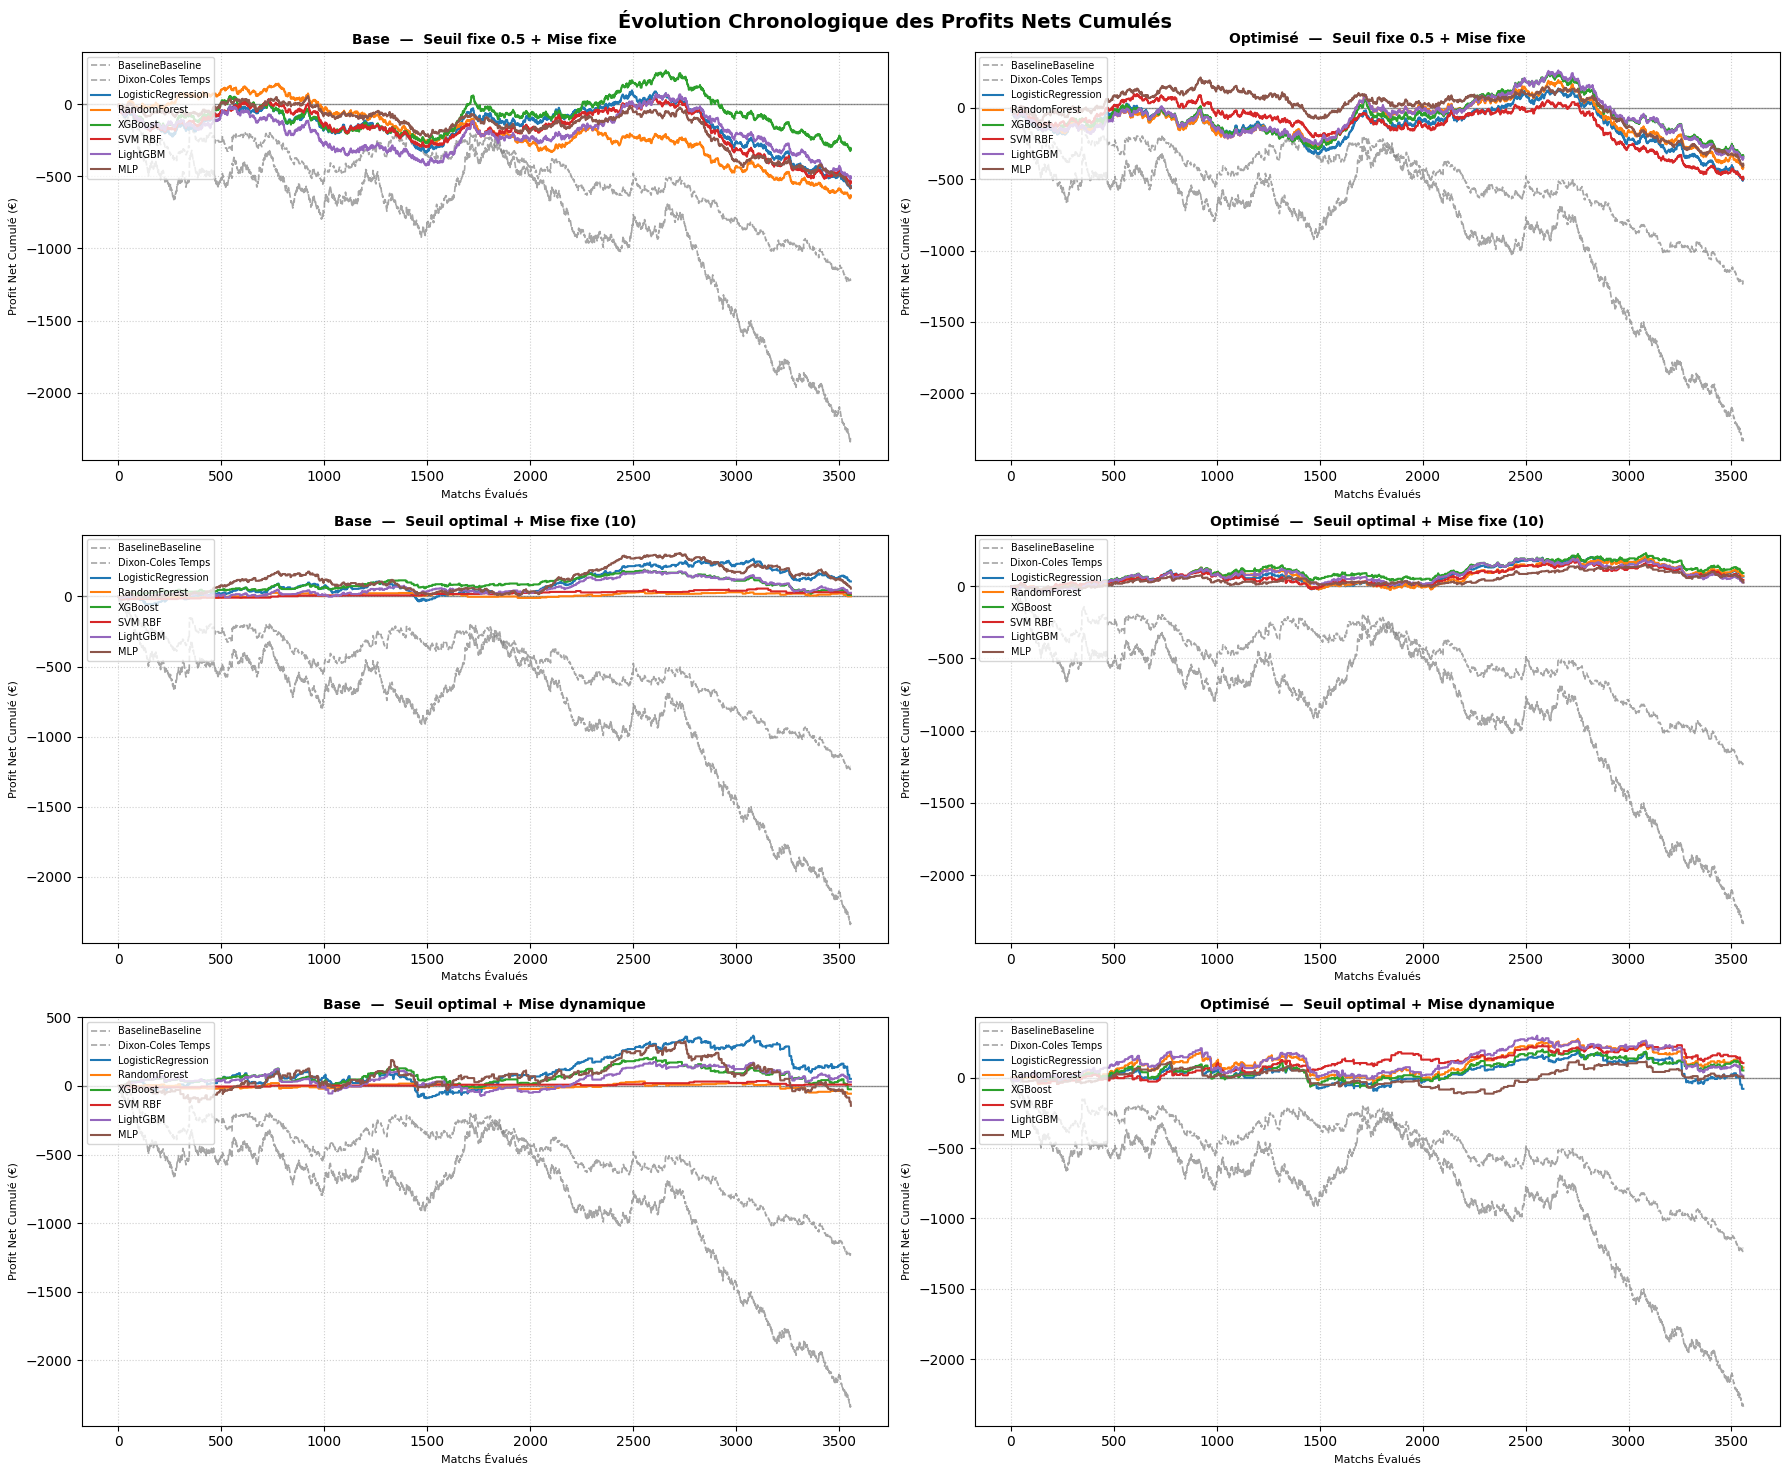

In [11]:
dict_profits_strat = {}

for nom, (probas, seuil, est_ml) in specs.items():
    seuil_concret = seuil if (seuil is not None) else SEUIL_SECURISE

    if est_ml:
        mask_05 = (probas >= 0.50)
    else:
        mask_05 = (probas > (1.0 / cotes_test))
    gains_05 = np.where(mask_05 & (y_test == 1), MISE * cotes_test, 0.0)
    profits_05 = gains_05 - np.where(mask_05, MISE, 0.0)
    dict_profits_strat[(nom, "seuil05")] = np.cumsum(profits_05)

    if nom == "Baseline (Toujours 1)":
        mask_opt = np.ones(len(probas), dtype=bool)
    elif est_ml:
        mask_opt = (probas >= seuil_concret)
    else:
        mask_opt = (probas > (1.0 / cotes_test))
    gains_opt = np.where(mask_opt & (y_test == 1), MISE * cotes_test, 0.0)
    profits_opt = gains_opt - np.where(mask_opt, MISE, 0.0)
    dict_profits_strat[(nom, "seuilopt")] = np.cumsum(profits_opt)

    prob_bk = 1.0 / cotes_test
    is_value = (probas > prob_bk)
    mises_dyn = np.zeros(len(probas))
    if est_ml and seuil is not None:
        mises_dyn[(probas >= seuil_concret) & (probas < seuil_concret + 0.10) & is_value] = 10.0
        mises_dyn[(probas >= seuil_concret + 0.10) & is_value] = 30.0
    else:
        mises_dyn[is_value] = MISE
    gains_dyn = np.where((mises_dyn > 0) & (y_test == 1), mises_dyn * cotes_test, 0.0)
    profits_dyn = gains_dyn - mises_dyn
    dict_profits_strat[(nom, "dyn")] = np.cumsum(profits_dyn)

strategies_plot = {"Seuil fixe 0.5 + Mise fixe": "seuil05", "Seuil optimal + Mise fixe (10)": "seuilopt",
                   "Seuil optimal + Mise dynamique": "dyn"}

categories_plot = {
    "Base": lambda n: ("(Base)" in n or "(base)" in n or "Stats" in n or "Toujours" in n),
    "Optimisé": lambda n: ("(Optimisé)" in n or "(optimisé)" in n or "Temps" in n or "Toujours" in n),
}

modeles_ref = ["Baseline (Toujours 1)", "Dixon-Coles (Optimisé + Temps)"]
couleurs = plt.cm.tab10.colors
index_matchs = np.arange(1, len(df_test) + 1)

fig, axes = plt.subplots(3, 2, figsize=(18, 15), sharey=False)
fig.suptitle("Évolution Chronologique des Profits Nets Cumulés", fontsize=14, fontweight='bold')

for row, (nom_strat, cle_strat) in enumerate(strategies_plot.items()):
    for col, (nom_cat, filtre_cat) in enumerate(categories_plot.items()):
        ax = axes[row][col]
        ax.axhline(y=0, color='black', linestyle='-', alpha=0.4, linewidth=1)
        ax.set_title(f"{nom_cat}  —  {nom_strat}", fontsize=10, fontweight='bold')
        ax.set_xlabel("Matchs Évalués", fontsize=8)
        ax.set_ylabel("Profit Net Cumulé (€)", fontsize=8)
        ax.grid(True, linestyle=':', alpha=0.6)

        for nom_ref in modeles_ref:
            cle = (nom_ref, cle_strat)
            if cle in dict_profits_strat:
                ax.plot(index_matchs, dict_profits_strat[cle],
                        label=nom_ref.replace(" (Toujours 1)", "Baseline").replace(" (Optimisé + Temps)", " Temps"),
                        linestyle='--', color='grey', alpha=0.7, linewidth=1.2)

        i_couleur = 0
        for nom_ml in modeles_ml.keys():
            if not filtre_cat(nom_ml):
                continue
            cle = (nom_ml, cle_strat)
            if cle in dict_profits_strat:
                nom_court = (nom_ml.replace(" (Optimisé)", "").replace(" (Base)", "").replace(" (base)", "").strip())
                ax.plot(index_matchs, dict_profits_strat[cle], label=nom_court, color=couleurs[i_couleur % len(couleurs)], linewidth=1.5)
            i_couleur += 1
        ax.legend(loc="upper left", fontsize=7, framealpha=0.8)

plt.tight_layout()
plt.show()

## Visualisation 2 : Histogramme des ROI Dynamiques

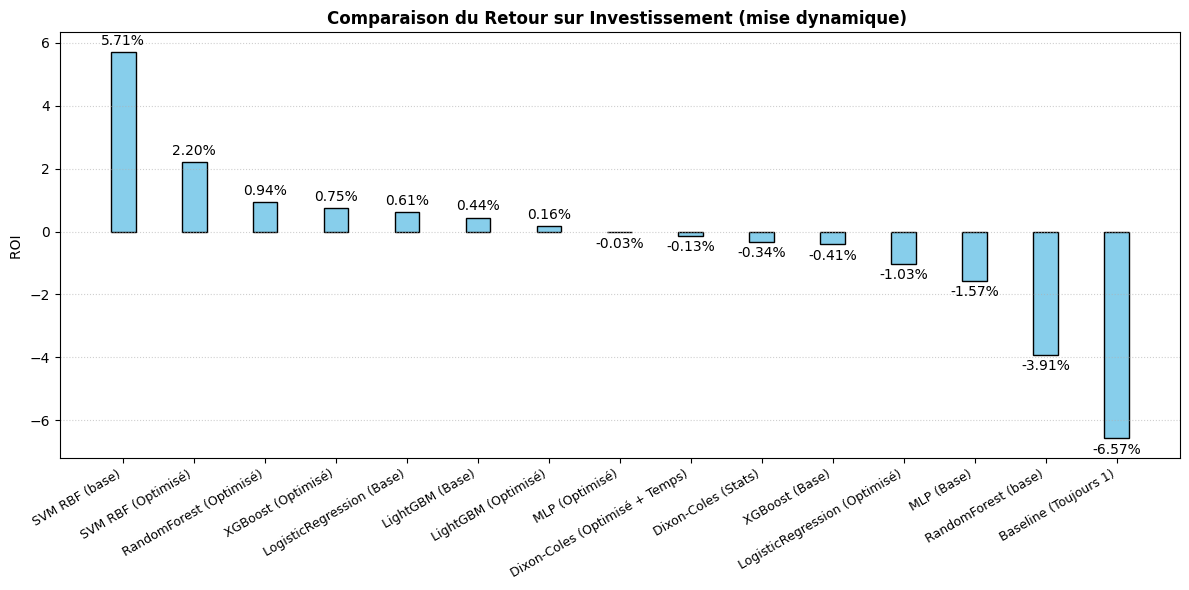

In [12]:
df_graphique = df_comparatif_trie
x = np.arange(len(df_graphique))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects = ax.bar(x, df_graphique["ROI Dyn Opti "], width, color='skyblue', edgecolor='black')

ax.set_title('Comparaison du Retour sur Investissement (mise dynamique) ', fontsize=12, fontweight='bold')
ax.set_ylabel('ROI ')
ax.set_xticks(x)
ax.set_xticklabels(df_graphique["Modèle"], rotation=30, ha="right", fontsize=9)
ax.grid(True, axis='y', linestyle=':', alpha=0.6)
ax.bar_label(rects, padding=3, fmt='%.2f%%')

plt.tight_layout()
plt.show()

## Visualisation 3 : Rendement par Stratégies de Mise

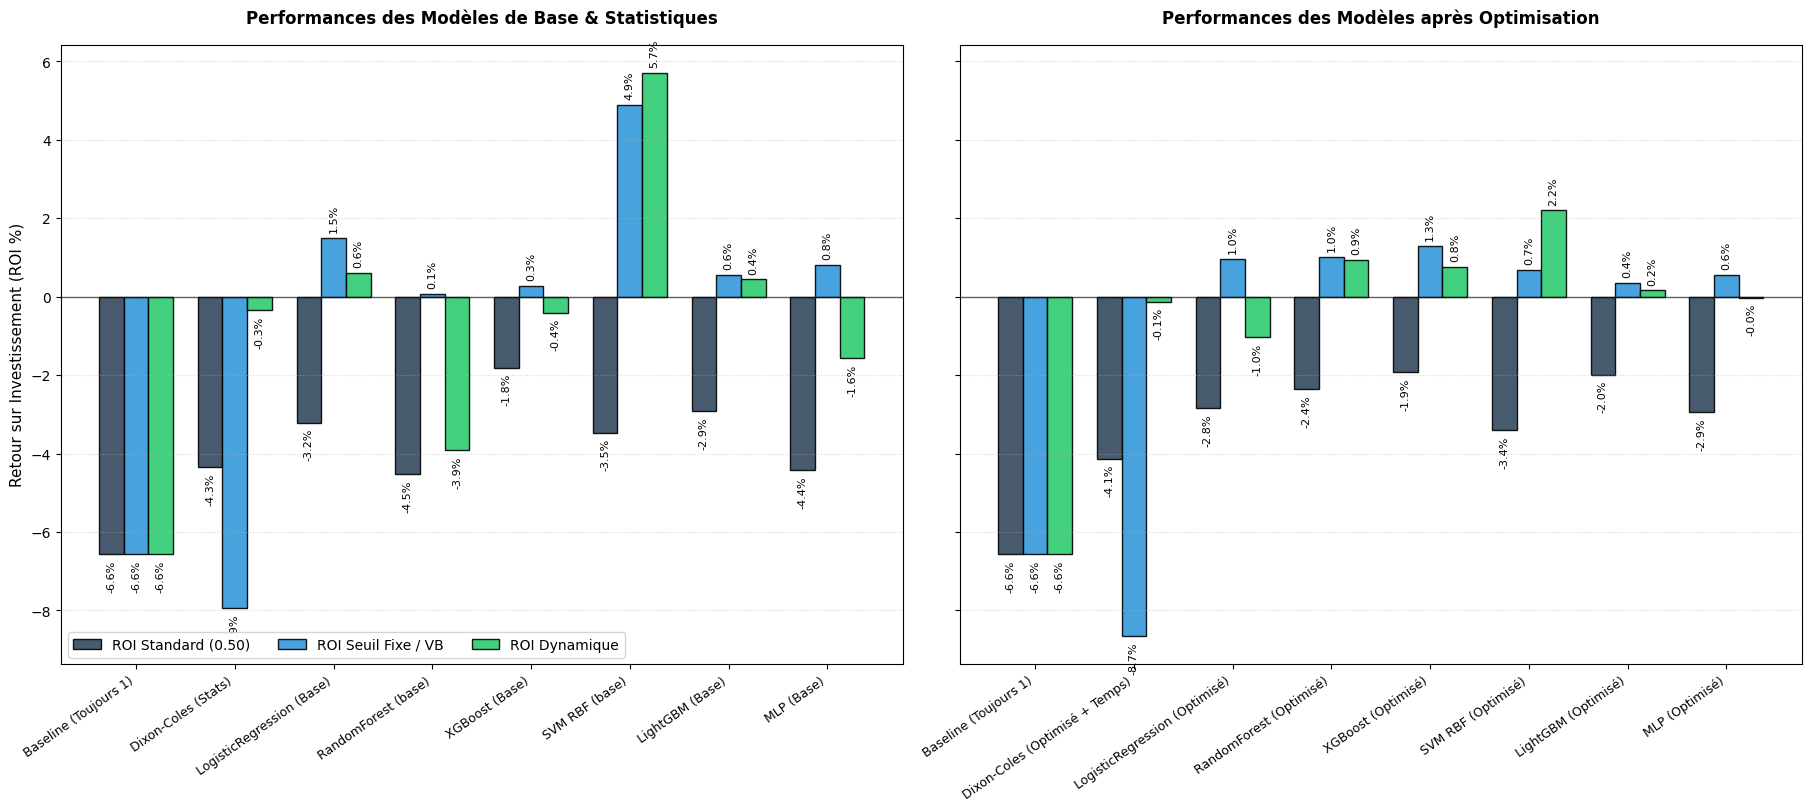

In [13]:
df_graph_base = df_comparatif[~df_comparatif["Modèle"].str.contains("Optimisé|optimisé")].copy()
df_graph_opti = df_comparatif[df_comparatif["Modèle"].str.contains("Optimisé|optimisé") | (df_comparatif["Modèle"] == "Baseline (Toujours 1)")].copy()

metriques_roi = ["ROI Std 0.50 ", "ROI Seuil opti ", "ROI Dyn Opti "]
couleurs_roi = ["#34495e", "#3498db", "#2ecc71"]
labels_barres = ["ROI Standard (0.50)", "ROI Seuil Fixe / VB", "ROI Dynamique"]

width = 0.25
x_base = np.arange(len(df_graph_base))
x_opti = np.arange(len(df_graph_opti))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharey=True, layout='constrained')

multiplier = 0
for metrique, color, label in zip(metriques_roi, couleurs_roi, labels_barres):
    valeurs = df_graph_base[metrique].round(2).tolist()
    offset = width * multiplier
    rects = ax1.bar(x_base + offset, valeurs, width, label=label, color=color, edgecolor="black", alpha=0.9)
    ax1.bar_label(rects, padding=4, rotation=90, fontsize=8, fmt='%.1f%%')
    multiplier += 1

ax1.set_title('Performances des Modèles de Base & Statistiques', fontsize=12, fontweight='bold', pad=15)
ax1.set_ylabel('Retour sur Investissement (ROI %)', fontsize=11)
ax1.set_xticks(x_base + width)
ax1.set_xticklabels(df_graph_base["Modèle"], rotation=35, ha="right", fontsize=9)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.6)
ax1.grid(True, axis='y', linestyle=':', alpha=0.5)

multiplier = 0
for metrique, color, label in zip(metriques_roi, couleurs_roi, labels_barres):
    valeurs = df_graph_opti[metrique].round(2).tolist()
    offset = width * multiplier
    rects = ax2.bar(x_opti + offset, valeurs, width, label=label, color=color, edgecolor="black", alpha=0.9)
    ax2.bar_label(rects, padding=4, rotation=90, fontsize=8, fmt='%.1f%%')
    multiplier += 1

ax2.set_title('Performances des Modèles après Optimisation', fontsize=12, fontweight='bold', pad=15)
ax2.set_xticks(x_opti + width)
ax2.set_xticklabels(df_graph_opti["Modèle"], rotation=35, ha="right", fontsize=9)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.6)
ax2.grid(True, axis='y', linestyle=':', alpha=0.5)

ax1.legend(loc='lower left', ncols=3, fontsize=10, frameon=True)
plt.savefig("comparatif_roi_structures.png", dpi=300, bbox_inches='tight')
plt.show()

## Tests de Significativité : Diagramme de Différence Critique (Log-Loss)

Test global de Friedman : Statistique = 133.268, P-value = 0.00000


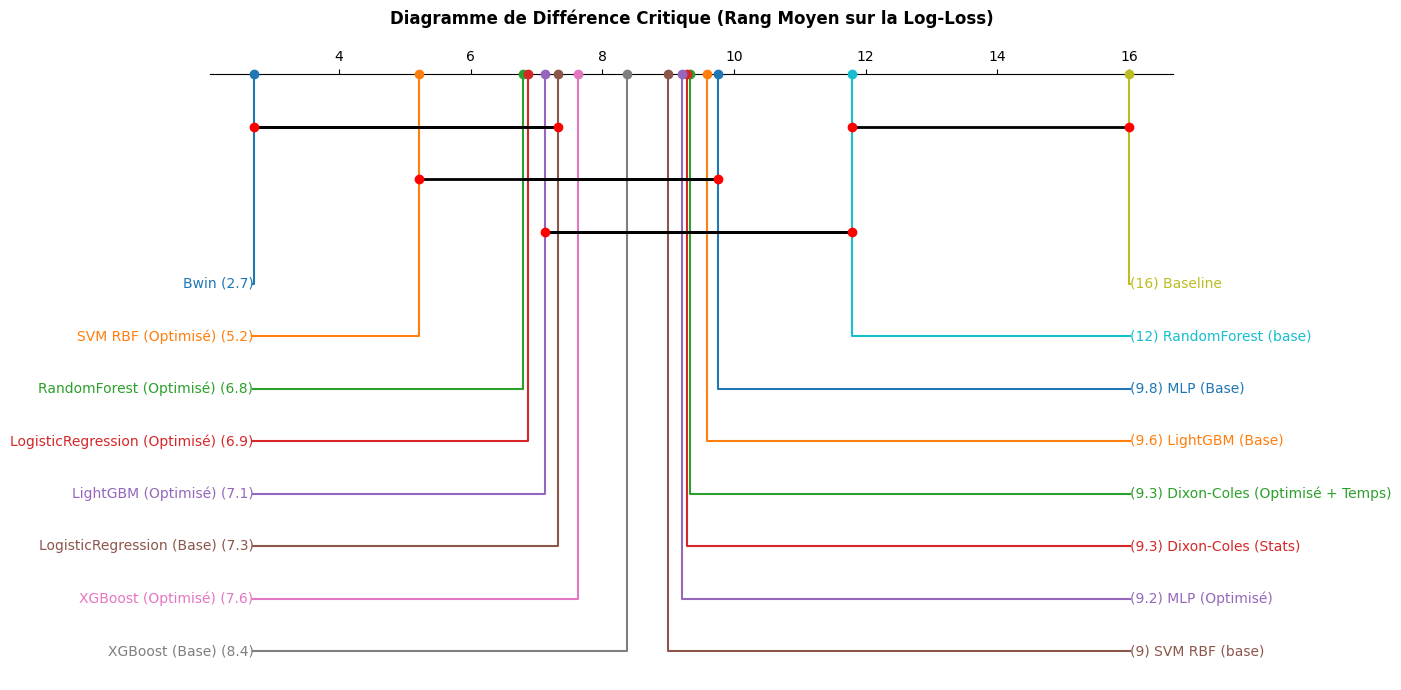

In [14]:
df_test_time = df.iloc[split_idx:].copy()

if 'Season' in df_test_time.columns and 'League' in df_test_time.columns and 'Date' in df_test_time.columns:
    df_test_time['Month'] = pd.to_datetime(df_test_time['Date']).dt.month
    df_test_time['Period'] = df_test_time['Month'].apply(lambda m: 'Part1' if m in [8, 9, 10, 11, 12] else 'Part2')
    group_col = df_test_time['Season'].astype(str) + "_" + df_test_time['League'].astype(str) + "_" + df_test_time['Period']
else:
    group_col = df_test_time['Season'].astype(str) + "_" + df_test_time['League'].astype(str) if 'Season' in df_test_time.columns else np.array(["Global"] * len(df_test_time))

loss_df = pd.DataFrame(index=df_test_time.index)
loss_df['Group_Period'] = group_col

for nom, probs in dict_probs_tous.items():
    nom_propre = nom.replace(" (Toujours 1)", "")
    p_c = np.clip(probs, 1e-15, 1 - 1e-15)
    loss_df[nom_propre] = -(y_test * np.log(p_c) + (1 - y_test) * np.log(1 - p_c))

bwh = pd.to_numeric(df_test_time['BWH']).values
bwd = pd.to_numeric(df_test_time['BWD']).values
bwa = pd.to_numeric(df_test_time['BWA']).values

margin = 1.0 / bwh + 1.0 / bwd + 1.0 / bwa
prob_bwin_h = np.clip((1.0 / bwh) / margin, 1e-15, 1 - 1e-15)
loss_df['Bwin'] = -(y_test * np.log(prob_bwin_h) + (1 - y_test) * np.log(1 - prob_bwin_h))
loss_df = loss_df.dropna()

scores_by_period = loss_df.groupby('Group_Period').mean()
scores_by_period.index.name = None

stat, p_value = stats.friedmanchisquare(*[scores_by_period[c] for c in scores_by_period.columns])
print(f"Test global de Friedman : Statistique = {stat:.3f}, P-value = {p_value:.5f}")

if p_value < 0.05:
    ranks_log_loss = scores_by_period.rank(axis=1, ascending=True).mean()
    p_matrix_logloss = sp.posthoc_nemenyi_friedman(scores_by_period)

    fig, ax = plt.subplots(figsize=(14, 7))
    result_ll = sp.critical_difference_diagram(ranks_log_loss, p_matrix_logloss, ax=ax)

    crossbars = result_ll["crossbars"]
    for group in crossbars:
        for line in group:
            x = line.get_xdata()
            y = line.get_ydata()
            ax.plot([np.min(x), np.max(x)], [y[0], y[0]], marker='o', markersize=6, color="red", linestyle='None', zorder=10)
    plt.title("Diagramme de Différence Critique (Rang Moyen sur la Log-Loss)", fontsize=12, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()
else:
    print("\n La p-value du test de Friedman est supérieure à 0.05.")

## Tests de Significativité : Diagramme de Différence Critique (Brier Score)

Test global de Friedman : Statistique = 125.702, P-value = 0.00000


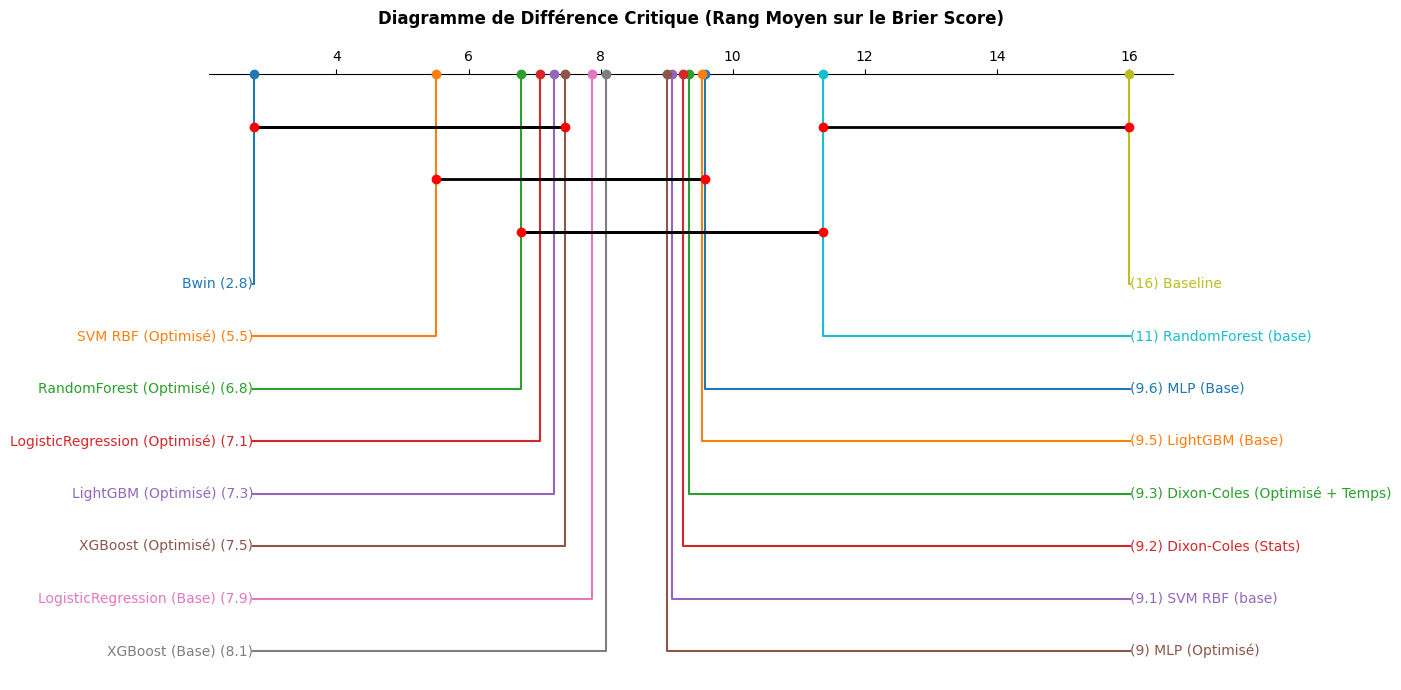

In [15]:
brier_df = pd.DataFrame(index=df_test_time.index)
brier_df['Group_Period'] = group_col

for nom, probs in dict_probs_tous.items():
    nom_propre = nom.replace(" (Toujours 1)", "")
    brier_df[nom_propre] = (probs - y_test) ** 2

brier_df['Bwin'] = (prob_bwin_h - y_test) ** 2
brier_df = brier_df.dropna()

scores_by_period_brier = brier_df.groupby('Group_Period').mean()
scores_by_period_brier.index.name = None

stat, p_value = stats.friedmanchisquare(*[scores_by_period_brier[c] for c in scores_by_period_brier.columns])
print(f"Test global de Friedman : Statistique = {stat:.3f}, P-value = {p_value:.5f}")

if p_value < 0.05:
    ranks_brier = scores_by_period_brier.rank(axis=1, ascending=True).mean()
    p_matrix_eqm = sp.posthoc_nemenyi_friedman(scores_by_period_brier)

    fig, ax = plt.subplots(figsize=(14, 7))
    result_eqm = sp.critical_difference_diagram(ranks_brier, p_matrix_eqm, ax=ax)

    if "crossbars" in result_eqm:
        for group in result_eqm["crossbars"]:
            for line in group:
                x = line.get_xdata()
                y = line.get_ydata()
                ax.plot([np.min(x), np.max(x)], [y[0], y[0]], marker='o', markersize=6, color="red", linestyle='None', zorder=10)

    plt.title("Diagramme de Différence Critique (Rang Moyen sur le Brier Score)", fontsize=12, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()
else:
    print("\nLa p-value du test de Friedman est supérieure à 0.05 pour le Brier Score.")

In [16]:
counts_paris = []

for nom, (probas, seuil, est_ml) in specs.items():
    if est_ml:
        mask_05 = (probas >= 0.50)
    else:
        mask_05 = (probas > (1.0 / cotes_test)) if nom != "Baseline (Toujours 1)" else np.ones(len(probas), dtype=bool)
    nb_paris_05 = int(mask_05.sum())

    seuil_concret = seuil if (seuil is not None) else SEUIL_SECURISE
    if nom == "Baseline (Toujours 1)":
        mask_sec = np.ones(len(probas), dtype=bool)
    elif est_ml:
        mask_sec = (probas >= seuil_concret)
    else:
        mask_sec = (probas > (1.0 / cotes_test))
    nb_paris_sec = int(mask_sec.sum())

    if nom == "Baseline (Toujours 1)":
        nb_paris_dyn = len(probas)
    else:
        prob_bk = 1.0 / cotes_test
        is_value = (probas > prob_bk)
        mises_dyn = np.zeros(len(probas))
        if est_ml and seuil is not None:
            mises_dyn[(probas >= seuil_concret) & (probas < seuil_concret + 0.10) & is_value] = 10.0
            mises_dyn[(probas >= seuil_concret + 0.10) & is_value] = 30.0
        else:
            mises_dyn[is_value] = MISE
        nb_paris_dyn = int((mises_dyn > 0).sum())

    counts_paris.append({
        "Modèle": nom,
        "Paris Standard": nb_paris_05,
        "Paris Seuil Opti": nb_paris_sec,
        "Paris Dyn Opti": nb_paris_dyn
    })

df_counts_paris = pd.DataFrame(counts_paris).sort_values("Paris Dyn Opti", ascending=True)

print("\n" + "=" * 90)
print("             Nb paris")
print("=" * 90)
print(df_counts_paris.to_string(index=False))



             Nb paris
                        Modèle  Paris Standard  Paris Seuil Opti  Paris Dyn Opti
                SVM RBF (base)            1558                42              17
           RandomForest (base)            1411               119              95
                MLP (Optimisé)            1358               453             246
            SVM RBF (Optimisé)            1445               627             311
                XGBoost (Base)            1718               394             329
               LightGBM (Base)            1738               478             387
            XGBoost (Optimisé)            1769               697             429
                    MLP (Base)            1312               703             446
 LogisticRegression (Optimisé)            1755               680             465
       RandomForest (Optimisé)            1776               700             466
           LightGBM (Optimisé)            1765               695             511
     